# Классификация текстов HateXplain

Цель работы — классифицировать сообщения датасета HateXplain
по трём классам:

- `normal`
- `offensive`
- `hatespeech`

Для классификации будет использован классический метод без трансформеров:
TF-IDF + LinearSVC.

In [1]:
import json
import pandas as pd
import numpy as np

from collections import Counter
from google.colab import files

In [2]:
uploaded = files.upload()

Saving dataset.json to dataset.json


In [3]:
with open("dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print("Количество записей:", len(data))

<class 'dict'>
Количество записей: 20148


In [4]:
rows = []

for post_id, item in data.items():
    labels = [ann["label"] for ann in item["annotators"]]
    counts = Counter(labels)

    final_label, count = counts.most_common(1)[0]

    if count < 2:
        final_label = None

    rows.append({
        "post_id": post_id,
        "text": " ".join(item["post_tokens"]),
        "label_1": labels[0],
        "label_2": labels[1],
        "label_3": labels[2],
        "final_label": final_label
    })

df = pd.DataFrame(rows)

print(df.shape)
df.head()

(20148, 6)


,post_id,text,label_1,label_2,label_3,final_label
0,1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,normal,normal,normal
1,1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,normal,normal,normal
2,1178793830532956161_twitter,nawt yall niggers ignoring me,normal,normal,hatespeech,normal
3,1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech,offensive,hatespeech,hatespeech
4,1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech,hatespeech,offensive,hatespeech


In [5]:
df["final_label"].value_counts(dropna=False)

,count
final_label,
normal,7814
hatespeech,5935
offensive,5480
None,919


## Подготовка данных

Сначала исключим сообщения, для которых среди трёх аннотаторов
не удалось определить итоговый класс по большинству голосов.

In [6]:
df_clean = df.dropna(subset=["final_label"]).copy()

print("Исходное количество:", len(df))
print("После удаления неоднозначных:", len(df_clean))

df_clean["final_label"].value_counts()

Исходное количество: 20148
После удаления неоднозначных: 19229


,count
final_label,
normal,7814
hatespeech,5935
offensive,5480


## Предобработка текста

Для текстов выполняется простая нормализация:

- приведение к нижнему регистру;
- удаление служебного токена `<user>`;
- замена `<number>` и `<percent>` на обычные слова;
- удаление лишних пробелов.

Сильную очистку, удаление стоп-слов и лемматизацию не используем,
так как отдельные слова и выражения могут быть важны для определения
токсичности сообщения.

In [7]:
import re

def preprocess_text(text):
    text = text.lower()

    text = text.replace("<user>", " ")
    text = text.replace("<number>", " number ")
    text = text.replace("<percent>", " percent ")

    text = re.sub(r"\s+", " ", text).strip()

    return text

df_clean["clean_text"] = df_clean["text"].apply(preprocess_text)

df_clean[["text", "clean_text", "final_label"]].head()

,text,clean_text,final_label
0,i dont think im getting my baby them white 9 h...,i dont think im getting my baby them white 9 h...,normal
1,we cannot continue calling ourselves feminists...,we cannot continue calling ourselves feminists...,normal
2,nawt yall niggers ignoring me,nawt yall niggers ignoring me,normal
3,<user> i am bit confused coz chinese ppl can n...,i am bit confused coz chinese ppl can not acce...,hatespeech
4,this bitch in whataburger eating a burger with...,this bitch in whataburger eating a burger with...,hatespeech


In [8]:
print("Количество записей:", len(df_clean))
print("Уникальных исходных текстов:", df_clean["text"].nunique())
print("Уникальных текстов после предобработки:", df_clean["clean_text"].nunique())

Количество записей: 19229
Уникальных исходных текстов: 19192
Уникальных текстов после предобработки: 19177


In [9]:
label_counts = (
    df_clean.groupby("clean_text")["final_label"]
    .nunique()
)

conflicting_texts = label_counts[label_counts > 1].index

print("Текстов с конфликтующими метками:", len(conflicting_texts))

Текстов с конфликтующими метками: 8


In [10]:
df_clean[df_clean["clean_text"].isin(conflicting_texts)][
    ["clean_text", "final_label"]
].sort_values("clean_text").head(20)

,clean_text,final_label
627,biggest coward chinaman satanist lee hsien loo...,normal
8281,biggest coward chinaman satanist lee hsien loo...,hatespeech
9932,ching chong,hatespeech
4896,ching chong,offensive
4708,he dindu nuffin,hatespeech
9498,he dindu nuffin,normal
803,he dindu nuffin,normal
3573,i fucking hate you,normal
9311,i fucking hate you,normal
13180,i fucking hate you,offensive


## Удаление конфликтующих записей и дубликатов

После нормализации некоторые одинаковые тексты имеют разные метки.
Такие записи удаляются полностью, поскольку для одного и того же текста
невозможно однозначно определить целевой класс.

Оставшиеся повторяющиеся тексты с одинаковыми метками также удаляются,
чтобы одинаковые сообщения не могли попасть одновременно в обучающую
и тестовую выборки.

In [11]:
# Удаляем все тексты с конфликтующими метками
df_final = df_clean[
    ~df_clean["clean_text"].isin(conflicting_texts)
].copy()

# Удаляем оставшиеся дубликаты с одинаковыми метками
df_final = df_final.drop_duplicates(
    subset=["clean_text"]
).reset_index(drop=True)

print("До очистки:", len(df_clean))
print("После удаления конфликтов и дубликатов:", len(df_final))

print("\nРаспределение классов:")
print(df_final["final_label"].value_counts())

print("\nПустых текстов:")
print((df_final["clean_text"] == "").sum())

До очистки: 19229
После удаления конфликтов и дубликатов: 19169

Распределение классов:
final_label
normal        7777
hatespeech    5926
offensive     5466
Name: count, dtype: int64

Пустых текстов:
0


## Разделение данных

Данные разделяются на три части:

- 70% — обучающая выборка;
- 15% — валидационная выборка;
- 15% — тестовая выборка.

Используется стратификация, чтобы распределение трёх классов
оставалось примерно одинаковым во всех выборках.

In [12]:
from sklearn.model_selection import train_test_split

X = df_final["clean_text"]
y = df_final["final_label"]

# Сначала отделяем 30% для validation + test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Делим оставшиеся 30% пополам: 15% validation и 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 13418
Validation: 2875
Test: 2876


In [13]:
print("Train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest:")
print(y_test.value_counts(normalize=True).round(3))

Train:
final_label
normal        0.406
hatespeech    0.309
offensive     0.285
Name: proportion, dtype: float64

Validation:
final_label
normal        0.406
hatespeech    0.309
offensive     0.285
Name: proportion, dtype: float64

Test:
final_label
normal        0.406
hatespeech    0.309
offensive     0.285
Name: proportion, dtype: float64


## Классификация текста

Для первого эксперимента используется сочетание TF-IDF и LinearSVC.

TF-IDF преобразует текст в числовое представление и придаёт больший вес
словам и сочетаниям слов, которые являются более характерными для
конкретных сообщений.

LinearSVC выбран как простой и эффективный линейный классификатор,
который хорошо подходит для разреженных TF-IDF-признаков.

На данном этапе качество модели оценивается на валидационной выборке.
Тестовая выборка будет использована только после выбора итоговых параметров.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(C=1.0)
    )
])

model.fit(X_train, y_train)

print("Модель обучена")

Модель обучена


In [15]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

y_val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print()
print(classification_report(y_val, y_val_pred, digits=4))

Validation Accuracy: 0.6365

              precision    recall  f1-score   support

  hatespeech     0.7376    0.7177    0.7275       889
      normal     0.6401    0.7290    0.6816      1166
   offensive     0.5015    0.4171    0.4554       820

    accuracy                         0.6365      2875
   macro avg     0.6264    0.6212    0.6215      2875
weighted avg     0.6307    0.6365    0.6313      2875



## Улучшение модели

Базовая модель показала недостаточное качество, особенно для класса
`offensive`.

Для улучшения представления текста добавляются символьные n-граммы.
Они позволяют учитывать части слов и варианты их написания, что может
быть полезно при классификации токсичных и оскорбительных сообщений.

В модели одновременно используются:

- TF-IDF по словам;
- TF-IDF по символам;
- LinearSVC с балансировкой классов.

In [16]:
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import accuracy_score, f1_score, classification_report

improved_model = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word_tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True
                )
            ),
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    min_df=2,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "classifier",
        LinearSVC(
            C=1.0,
            class_weight="balanced"
        )
    )
])

improved_model.fit(X_train, y_train)

y_val_pred_improved = improved_model.predict(X_val)

accuracy = accuracy_score(y_val, y_val_pred_improved)
macro_f1 = f1_score(y_val, y_val_pred_improved, average="macro")

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print()
print(classification_report(
    y_val,
    y_val_pred_improved,
    digits=4
))

Validation Accuracy: 0.6348
Macro F1: 0.6219

              precision    recall  f1-score   support

  hatespeech     0.7279    0.7132    0.7205       889
      normal     0.6627    0.7127    0.6868      1166
   offensive     0.4800    0.4390    0.4586       820

    accuracy                         0.6348      2875
   macro avg     0.6235    0.6216    0.6219      2875
weighted avg     0.6307    0.6348    0.6321      2875



In [17]:
def get_agreement(row):
    labels = [row["label_1"], row["label_2"], row["label_3"]]
    return max(Counter(labels).values())

df["agreement"] = df.apply(get_agreement, axis=1)

df["agreement"].value_counts().sort_index()

,count
agreement,
1,919
2,9384
3,9845


In [18]:
val_results = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "pred_label": y_val_pred
})

val_results["correct"] = (
    val_results["true_label"] == val_results["pred_label"]
)

val_results = val_results.merge(
    df[["text", "agreement"]],
    left_on="text",
    right_on="text",
    how="left"
)

val_results.groupby("agreement")["correct"].agg(
    ["count", "mean"]
)

,count,mean
agreement,,
2.0,981,0.516820
3.0,971,0.754892


In [19]:
df_clean["agreement"] = df_clean.apply(
    get_agreement,
    axis=1
)

df_final = df_clean[
    ~df_clean["clean_text"].isin(conflicting_texts)
].copy()

df_final = df_final.drop_duplicates(
    subset=["clean_text"]
).reset_index(drop=True)

## Проверка влияния качества разметки

В исходном HateXplain часть сообщений имеет полное согласие трёх
аннотаторов, а часть получает итоговую метку только по большинству 2 из 3.

Поскольку неоднозначная разметка может ограничивать качество модели,
дополнительно проверим классификацию на подмножестве сообщений,
для которых все три аннотатора выбрали один класс.

In [20]:
df_high_conf = df_final[
    df_final["agreement"] == 3
].copy()

print("Количество объектов:", len(df_high_conf))
print()
print(df_high_conf["final_label"].value_counts())

Количество объектов: 9818

final_label
normal        5104
hatespeech    2957
offensive     1757
Name: count, dtype: int64


In [21]:
X_h = df_high_conf["clean_text"]
y_h = df_high_conf["final_label"]

X_train_h, X_temp_h, y_train_h, y_temp_h = train_test_split(
    X_h,
    y_h,
    test_size=0.30,
    random_state=42,
    stratify=y_h
)

X_val_h, X_test_h, y_val_h, y_test_h = train_test_split(
    X_temp_h,
    y_temp_h,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_h
)

print("Train:", len(X_train_h))
print("Validation:", len(X_val_h))
print("Test:", len(X_test_h))

Train: 6872
Validation: 1473
Test: 1473


In [22]:
high_conf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(C=1.0)
    )
])

high_conf_model.fit(X_train_h, y_train_h)

y_val_pred_h = high_conf_model.predict(X_val_h)

print(
    f"Validation Accuracy: "
    f"{accuracy_score(y_val_h, y_val_pred_h):.4f}"
)
print()

print(
    classification_report(
        y_val_h,
        y_val_pred_h,
        digits=4
    )
)

Validation Accuracy: 0.7671

              precision    recall  f1-score   support

  hatespeech     0.8285    0.7743    0.8005       443
      normal     0.7699    0.8734    0.8183       766
   offensive     0.6211    0.4470    0.5198       264

    accuracy                         0.7671      1473
   macro avg     0.7398    0.6982    0.7129      1473
weighted avg     0.7608    0.7671    0.7595      1473



## Подбор параметра C

После фильтрации данных по качеству разметки точность выросла до 76,71%.

Для дальнейшего улучшения модели подберём параметр регуляризации `C`
у LinearSVC по валидационной выборке.

Тестовая выборка на этом этапе не используется.

In [23]:
from sklearn.metrics import accuracy_score, f1_score

results = []

for C in [0.1, 0.25, 0.5, 1.0, 2.0, 4.0]:

    current_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LinearSVC(C=C)
        )
    ])

    current_model.fit(X_train_h, y_train_h)

    pred = current_model.predict(X_val_h)

    acc = accuracy_score(y_val_h, pred)
    macro_f1 = f1_score(y_val_h, pred, average="macro")

    results.append({
        "C": C,
        "accuracy": acc,
        "macro_f1": macro_f1
    })

results_df = pd.DataFrame(results)
results_df

,C,accuracy,macro_f1
0,0.10,0.766463,0.692937
1,0.25,0.773931,0.708997
2,0.50,0.768500,0.711377
3,1.00,0.767142,0.712880
4,2.00,0.754243,0.700418
5,4.00,0.748812,0.693321


In [24]:
results_df.sort_values(
    by="accuracy",
    ascending=False
)

,C,accuracy,macro_f1
1,0.25,0.773931,0.708997
2,0.50,0.768500,0.711377
3,1.00,0.767142,0.712880
0,0.10,0.766463,0.692937
4,2.00,0.754243,0.700418
5,4.00,0.748812,0.693321


## Добавление символьных признаков

После отбора сообщений с согласованной разметкой и подбора параметра `C`
лучшая точность составила 77,39%.

Дополнительно проверим сочетание словных и символьных TF-IDF-признаков.
Символьные n-граммы могут учитывать части слов, опечатки и варианты
написания токсичной лексики.

In [25]:
from sklearn.pipeline import FeatureUnion

word_char_model = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word_tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True
                )
            ),
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    min_df=2,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "classifier",
        LinearSVC(C=0.25)
    )
])

word_char_model.fit(X_train_h, y_train_h)

y_val_pred_wc = word_char_model.predict(X_val_h)

wc_accuracy = accuracy_score(y_val_h, y_val_pred_wc)
wc_macro_f1 = f1_score(
    y_val_h,
    y_val_pred_wc,
    average="macro"
)

print(f"Validation Accuracy: {wc_accuracy:.4f}")
print(f"Macro F1: {wc_macro_f1:.4f}")
print()
print(
    classification_report(
        y_val_h,
        y_val_pred_wc,
        digits=4
    )
)

Validation Accuracy: 0.7895
Macro F1: 0.7289

              precision    recall  f1-score   support

  hatespeech     0.8689    0.8081    0.8374       443
      normal     0.7822    0.9047    0.8390       766
   offensive     0.6400    0.4242    0.5103       264

    accuracy                         0.7895      1473
   macro avg     0.7637    0.7124    0.7289      1473
weighted avg     0.7828    0.7895    0.7796      1473



## Подбор параметров улучшенной модели

Сочетание словных и символьных TF-IDF-признаков повысило точность
на валидационной выборке до 78,95%.

Для выбора итоговой модели дополнительно проверим несколько значений
параметра `C` и использование балансировки классов.

Все параметры подбираются только на валидационной выборке.
Тестовая выборка на этом этапе не используется.

In [26]:
tuning_results = []

for C in [0.1, 0.2, 0.25, 0.3, 0.5]:
    for class_weight in [None, "balanced"]:

        current_model = Pipeline([
            (
                "features",
                FeatureUnion([
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            analyzer="word",
                            ngram_range=(1, 2),
                            min_df=2,
                            sublinear_tf=True
                        )
                    ),
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char_wb",
                            ngram_range=(3, 5),
                            min_df=2,
                            sublinear_tf=True
                        )
                    )
                ])
            ),
            (
                "classifier",
                LinearSVC(
                    C=C,
                    class_weight=class_weight
                )
            )
        ])

        current_model.fit(X_train_h, y_train_h)

        pred = current_model.predict(X_val_h)

        acc = accuracy_score(y_val_h, pred)
        macro_f1 = f1_score(
            y_val_h,
            pred,
            average="macro"
        )

        tuning_results.append({
            "C": C,
            "class_weight": str(class_weight),
            "accuracy": acc,
            "macro_f1": macro_f1
        })

tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values(
    by=["accuracy", "macro_f1"],
    ascending=False
)

,C,class_weight,accuracy,macro_f1
3,0.20,balanced,0.792940,0.746197
1,0.10,balanced,0.792940,0.743025
5,0.25,balanced,0.792261,0.746933
6,0.30,None,0.790224,0.732608
4,0.25,None,0.789545,0.728887
7,0.30,balanced,0.788187,0.742992
9,0.50,balanced,0.787508,0.742858
0,0.10,None,0.786151,0.721239
2,0.20,None,0.785472,0.723467
8,0.50,None,0.780720,0.727038


In [27]:
LinearSVC(
    C=0.20,
    class_weight="balanced"
)

LinearSVC(C=0.2, class_weight='balanced')

## Финальный подбор TF-IDF-признаков

Лучший результат после подбора параметров LinearSVC составил 79,29%.

Для финального выбора модели проверим несколько вариантов диапазонов
словных и символьных n-грамм, сохраняя параметры классификатора
`C=0.20` и `class_weight="balanced"`.

После этого дополнительные параметры подбирать не будем.

In [28]:
feature_configs = [
    {
        "name": "word_1_2 + char_3_5",
        "word_ngram": (1, 2),
        "char_ngram": (3, 5)
    },
    {
        "name": "word_1_3 + char_3_5",
        "word_ngram": (1, 3),
        "char_ngram": (3, 5)
    },
    {
        "name": "word_1_2 + char_2_5",
        "word_ngram": (1, 2),
        "char_ngram": (2, 5)
    },
    {
        "name": "word_1_2 + char_3_6",
        "word_ngram": (1, 2),
        "char_ngram": (3, 6)
    }
]

feature_results = []

for config in feature_configs:

    current_model = Pipeline([
        (
            "features",
            FeatureUnion([
                (
                    "word_tfidf",
                    TfidfVectorizer(
                        analyzer="word",
                        ngram_range=config["word_ngram"],
                        min_df=2,
                        sublinear_tf=True
                    )
                ),
                (
                    "char_tfidf",
                    TfidfVectorizer(
                        analyzer="char_wb",
                        ngram_range=config["char_ngram"],
                        min_df=2,
                        sublinear_tf=True
                    )
                )
            ])
        ),
        (
            "classifier",
            LinearSVC(
                C=0.20,
                class_weight="balanced"
            )
        )
    ])

    current_model.fit(X_train_h, y_train_h)

    pred = current_model.predict(X_val_h)

    acc = accuracy_score(y_val_h, pred)
    macro_f1 = f1_score(
        y_val_h,
        pred,
        average="macro"
    )

    feature_results.append({
        "features": config["name"],
        "accuracy": acc,
        "macro_f1": macro_f1
    })

feature_results_df = pd.DataFrame(feature_results)

feature_results_df.sort_values(
    by=["accuracy", "macro_f1"],
    ascending=False
)

,features,accuracy,macro_f1
3,word_1_2 + char_3_6,0.793618,0.747290
1,word_1_3 + char_3_5,0.792940,0.747390
0,word_1_2 + char_3_5,0.792940,0.746197
2,word_1_2 + char_2_5,0.790224,0.743503


## Финальная модель

По результатам экспериментов была выбрана модель LinearSVC со следующими параметрами:

- словные TF-IDF n-граммы: `(1, 2)`;
- символьные TF-IDF n-граммы: `(3, 6)`;
- `C = 0.20`;
- `class_weight = "balanced"`.

Лучшая точность на валидационной выборке составила 79,36%.

После выбора параметров обучающая и валидационная выборки объединяются.
Итоговая модель переобучается на этих данных и один раз оценивается
на ранее не использованной тестовой выборке.

In [29]:
X_train_final = pd.concat([X_train_h, X_val_h])
y_train_final = pd.concat([y_train_h, y_val_h])

print("Train + Validation:", len(X_train_final))
print("Test:", len(X_test_h))

Train + Validation: 8345
Test: 1473


In [30]:
final_model = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word_tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True
                )
            ),
            (
                "char_tfidf",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    min_df=2,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "classifier",
        LinearSVC(
            C=0.20,
            class_weight="balanced"
        )
    )
])

final_model.fit(X_train_final, y_train_final)

print("Финальная модель обучена")

Финальная модель обучена


In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_test_pred = final_model.predict(X_test_h)

test_accuracy = accuracy_score(y_test_h, y_test_pred)
test_macro_f1 = f1_score(
    y_test_h,
    y_test_pred,
    average="macro"
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print()

print(
    classification_report(
        y_test_h,
        y_test_pred,
        digits=4
    )
)

Test Accuracy: 0.7814
Test Macro F1: 0.7171

              precision    recall  f1-score   support

  hatespeech     0.8490    0.8356    0.8422       444
      normal     0.8017    0.8760    0.8372       766
   offensive     0.5477    0.4144    0.4719       263

    accuracy                         0.7814      1473
   macro avg     0.7328    0.7087    0.7171      1473
weighted avg     0.7706    0.7814    0.7735      1473



## Анализ ошибок модели

После финального тестирования проанализируем объекты,
которые модель классифицировала неправильно.

Цель анализа — определить, какие классы модель путает чаще всего
и какие особенности текста могут приводить к ошибкам.

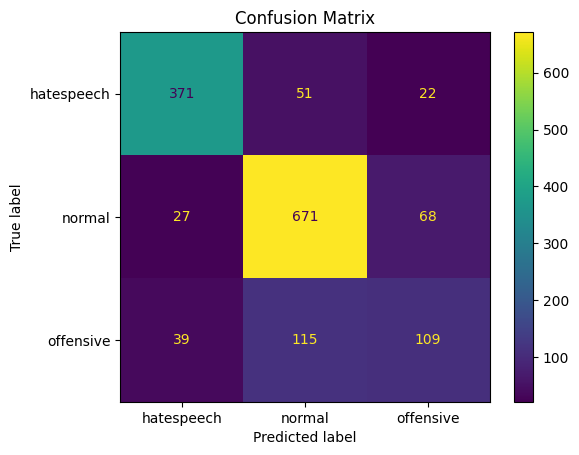

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["hatespeech", "normal", "offensive"]

cm = confusion_matrix(
    y_test_h,
    y_test_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [33]:
error_analysis = pd.DataFrame({
    "text": X_test_h.values,
    "true_label": y_test_h.values,
    "predicted_label": y_test_pred
})

errors = error_analysis[
    error_analysis["true_label"] !=
    error_analysis["predicted_label"]
].copy()

print("Ошибочно классифицировано:", len(errors))
print()
errors.head(20)

Ошибочно классифицировано: 322



,text,true_label,predicted_label
1,people think it ’ ok to go after jews now and ...,normal,offensive
6,lmfaoo ya moms a hoe,normal,offensive
10,she will blame it on jews or trump i bet,offensive,hatespeech
12,why are white guys always such whiny little bi...,normal,offensive
13,seems like the only purpose to christianity an...,offensive,normal
14,henry ford more like henry hated the jews,normal,offensive
16,dick pics from the muslimes and sexual violenc...,offensive,normal
22,the mcu wants what disaster report by matthew ...,normal,offensive
24,i want to jimmy kimmel to do one of those ate ...,hatespeech,normal
26,we need to respect muslim army because they ar...,normal,hatespeech


In [34]:
error_counts = (
    errors.groupby(
        ["true_label", "predicted_label"]
    )
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_counts

,true_label,predicted_label,count
5,offensive,normal,115
3,normal,offensive,68
0,hatespeech,normal,51
4,offensive,hatespeech,39
2,normal,hatespeech,27
1,hatespeech,offensive,22


In [35]:
errors[
    (errors["true_label"] == "offensive") &
    (errors["predicted_label"] == "normal")
][
    ["text", "true_label", "predicted_label"]
].head(10)

,text,true_label,predicted_label
13,seems like the only purpose to christianity an...,offensive,normal
16,dick pics from the muslimes and sexual violenc...,offensive,normal
35,we have a lot refugees we can share a little b...,offensive,normal
45,hintington tx quotes from our mayor in open me...,offensive,normal
48,how do jews use the state or any organizationa...,offensive,normal
57,black men prefer big banging ghetto blasters w...,offensive,normal
66,lol here the other crazy bitch go read the oth...,offensive,normal
73,no idea what in the hell this one is for or ab...,offensive,normal
79,there a bunch of faggots in my 1 st period com...,offensive,normal
137,space is gay and so are you,offensive,normal


In [36]:
errors[
    (errors["true_label"] == "offensive") &
    (errors["predicted_label"] == "hatespeech")
][
    ["text", "true_label", "predicted_label"]
].head(10)

,text,true_label,predicted_label
10,she will blame it on jews or trump i bet,offensive,hatespeech
34,well at least the mudslimes occasionally get i...,offensive,hatespeech
62,sup you fuckin gay piece of shit,offensive,hatespeech
181,kike jags up by number tds how dose that feel ...,offensive,hatespeech
270,amen we need whites number make invent enuff s...,offensive,hatespeech
286,so why is not the muslim world sending million...,offensive,hatespeech
339,imma do you faggots like the left the gods today,offensive,hatespeech
388,john i do not hate white people i am not like ...,offensive,hatespeech
482,seems the london muzzies get a taste of their ...,offensive,hatespeech
536,lol returning to cville is badass go ahead and...,offensive,hatespeech


In [37]:
errors[
    (errors["true_label"] == "hatespeech") &
    (errors["predicted_label"] == "offensive")
][
    ["text", "true_label", "predicted_label"]
].head(10)

,text,true_label,predicted_label
100,willard spratt willard spratt number hours ago...,hatespeech,offensive
233,look at what you wrote you ironic faggot you q...,hatespeech,offensive
259,paul and jayda keep up your battle of britain ...,hatespeech,offensive
264,another ghetto hell hag who is deeply upset go...,hatespeech,offensive
289,the baptist church and its retarded disciples ...,hatespeech,offensive
445,you are confusing ghetto niggas with christian...,hatespeech,offensive
446,i am a white nationalist neo nazi everything i...,hatespeech,offensive
448,rosie o makes me physically sick looking at he...,hatespeech,offensive
562,you niggas faggots putting you all hands on fe...,hatespeech,offensive
593,it painfully clear why mudslime throw these pe...,hatespeech,offensive


### Вывод по анализу ошибок

На тестовой выборке модель неправильно классифицировала 322 из 1473 сообщений.

Наиболее частая ошибка — отнесение сообщений класса `offensive` к классу
`normal` (115 случаев). Класс `offensive` оказался самым сложным для модели:
его recall составил 0,4144, а F1-score — 0,4719.

Также модель иногда путает `offensive` и `hatespeech`. В таких сообщениях
часто встречаются оскорбления и упоминания различных групп людей,
поэтому одних лексических признаков недостаточно для точного разделения
этих классов.

Ошибки показывают ограничение выбранного метода: TF-IDF и LinearSVC
хорошо учитывают наличие слов, сочетаний слов и частей слов, но хуже
работают со сложным контекстом, иронией и направленностью высказывания.

При этом классы `hatespeech` и `normal` распознаются значительно лучше:
их F1-score на тестовой выборке составил 0,8422 и 0,8372 соответственно.

## Итог классификации

Первоначальная модель TF-IDF + LinearSVC на данных с разметкой по
большинству голосов показала точность 63,65%.

После отбора сообщений с полным согласием трёх аннотаторов точность
той же базовой модели выросла до 76,71%. Это показало заметное влияние
качества разметки на результат классификации.

После подбора параметров и добавления словных и символьных TF-IDF-признаков
лучшая точность на валидационной выборке составила 79,36%.

Для итоговой модели использованы:

- словные n-граммы `(1, 2)`;
- символьные n-граммы `(3, 6)`;
- LinearSVC с `C=0.20`;
- `class_weight="balanced"`.

После окончательного выбора параметров модель была переобучена на
объединённых обучающей и валидационной выборках.

Итоговая точность на ранее не использованной тестовой выборке составила
**78,14%**, Macro F1 — **0,7171**.

Основным источником ошибок оказался класс `offensive`, который часто
пересекается по смыслу и лексике с классами `normal` и `hatespeech`.

## Ансамбль моделей

Для получения дополнительной оценки дополнительно реализован ансамбль
из трёх методов классификации:

- LinearSVC;
- Logistic Regression;
- Complement Naive Bayes.

Все модели используют одинаковое TF-IDF-представление текста.
Предсказания моделей объединяются с разными весами.

Веса подбираются только на валидационной выборке.
Тестовая выборка при подборе весов не используется.

In [38]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

ensemble_features = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 6),
            min_df=2,
            sublinear_tf=True
        )
    )
])

X_train_features = ensemble_features.fit_transform(X_train_h)
X_val_features = ensemble_features.transform(X_val_h)

print("Train shape:", X_train_features.shape)
print("Validation shape:", X_val_features.shape)

Train shape: (6872, 77109)
Validation shape: (1473, 77109)


In [39]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB

svc_model = LinearSVC(
    C=0.20,
    class_weight="balanced"
)

lr_model = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=2000
)

nb_model = ComplementNB(
    alpha=1.0
)

svc_model.fit(X_train_features, y_train_h)
lr_model.fit(X_train_features, y_train_h)
nb_model.fit(X_train_features, y_train_h)

print("Все три модели обучены")

Все три модели обучены


In [40]:
from scipy.special import softmax
import numpy as np

svc_scores = softmax(
    svc_model.decision_function(X_val_features),
    axis=1
)

lr_scores = lr_model.predict_proba(X_val_features)
nb_scores = nb_model.predict_proba(X_val_features)

print("Классы SVC:", svc_model.classes_)
print("Классы LR:", lr_model.classes_)
print("Классы NB:", nb_model.classes_)

assert np.array_equal(svc_model.classes_, lr_model.classes_)
assert np.array_equal(svc_model.classes_, nb_model.classes_)

classes = svc_model.classes_

Классы SVC: ['hatespeech' 'normal' 'offensive']
Классы LR: ['hatespeech' 'normal' 'offensive']
Классы NB: ['hatespeech' 'normal' 'offensive']


In [41]:
ensemble_results = []

for svc_part in range(1, 9):
    for lr_part in range(1, 10 - svc_part):

        nb_part = 10 - svc_part - lr_part

        if nb_part < 1:
            continue

        w_svc = svc_part / 10
        w_lr = lr_part / 10
        w_nb = nb_part / 10

        combined_scores = (
            w_svc * svc_scores +
            w_lr * lr_scores +
            w_nb * nb_scores
        )

        pred = classes[
            np.argmax(combined_scores, axis=1)
        ]

        acc = accuracy_score(y_val_h, pred)
        macro_f1 = f1_score(
            y_val_h,
            pred,
            average="macro"
        )

        ensemble_results.append({
            "svc_weight": w_svc,
            "lr_weight": w_lr,
            "nb_weight": w_nb,
            "accuracy": acc,
            "macro_f1": macro_f1
        })

ensemble_results_df = pd.DataFrame(
    ensemble_results
)

ensemble_results_df.sort_values(
    by=["accuracy", "macro_f1"],
    ascending=False
).head(10)

,svc_weight,lr_weight,nb_weight,accuracy,macro_f1
34,0.7,0.2,0.1,0.794297,0.745639
29,0.5,0.4,0.1,0.792261,0.744952
35,0.8,0.1,0.1,0.790903,0.739895
32,0.6,0.3,0.1,0.790224,0.741598
19,0.3,0.5,0.2,0.789545,0.738220
20,0.3,0.6,0.1,0.788866,0.742688
13,0.2,0.6,0.2,0.788187,0.737405
6,0.1,0.7,0.2,0.788187,0.737172
24,0.4,0.4,0.2,0.788187,0.735967
28,0.5,0.3,0.2,0.788187,0.735780


## Финальный ансамбль моделей

Для ансамбля использованы три классификатора:

- LinearSVC;
- Logistic Regression;
- Complement Naive Bayes.

На валидационной выборке были подобраны веса их предсказаний.

Лучший результат получен при следующих весах:

- LinearSVC — 0,7;
- Logistic Regression — 0,2;
- Complement Naive Bayes — 0,1.

Точность ансамбля на валидационной выборке составила 79,43%.

После выбора весов модели переобучаются на объединённых
обучающей и валидационной выборках и оцениваются на тестовой выборке.

In [42]:
X_train_ensemble = pd.concat([X_train_h, X_val_h])
y_train_ensemble = pd.concat([y_train_h, y_val_h])

final_features = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 6),
            min_df=2,
            sublinear_tf=True
        )
    )
])

X_train_ensemble_features = final_features.fit_transform(
    X_train_ensemble
)

X_test_ensemble_features = final_features.transform(
    X_test_h
)

print("Train + Validation:", X_train_ensemble_features.shape)
print("Test:", X_test_ensemble_features.shape)

Train + Validation: (8345, 87267)
Test: (1473, 87267)


In [43]:
final_svc = LinearSVC(
    C=0.20,
    class_weight="balanced"
)

final_lr = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    max_iter=2000
)

final_nb = ComplementNB(
    alpha=1.0
)

final_svc.fit(
    X_train_ensemble_features,
    y_train_ensemble
)

final_lr.fit(
    X_train_ensemble_features,
    y_train_ensemble
)

final_nb.fit(
    X_train_ensemble_features,
    y_train_ensemble
)

print("Финальные модели ансамбля обучены")

Финальные модели ансамбля обучены


In [44]:
svc_test_scores = softmax(
    final_svc.decision_function(
        X_test_ensemble_features
    ),
    axis=1
)

lr_test_scores = final_lr.predict_proba(
    X_test_ensemble_features
)

nb_test_scores = final_nb.predict_proba(
    X_test_ensemble_features
)

classes = final_svc.classes_

ensemble_test_scores = (
    0.7 * svc_test_scores +
    0.2 * lr_test_scores +
    0.1 * nb_test_scores
)

y_test_pred_ensemble = classes[
    np.argmax(
        ensemble_test_scores,
        axis=1
    )
]

In [45]:
ensemble_test_accuracy = accuracy_score(
    y_test_h,
    y_test_pred_ensemble
)

ensemble_test_macro_f1 = f1_score(
    y_test_h,
    y_test_pred_ensemble,
    average="macro"
)

print(
    f"Ensemble Test Accuracy: "
    f"{ensemble_test_accuracy:.4f}"
)

print(
    f"Ensemble Test Macro F1: "
    f"{ensemble_test_macro_f1:.4f}"
)

print()

print(
    classification_report(
        y_test_h,
        y_test_pred_ensemble,
        digits=4
    )
)

Ensemble Test Accuracy: 0.7841
Ensemble Test Macro F1: 0.7179

              precision    recall  f1-score   support

  hatespeech     0.8592    0.8243    0.8414       444
      normal     0.7923    0.8916    0.8391       766
   offensive     0.5730    0.4030    0.4732       263

    accuracy                         0.7841      1473
   macro avg     0.7415    0.7063    0.7179      1473
weighted avg     0.7733    0.7841    0.7744      1473

